---
## Class Exercise 💪 💻


**Remember:**
- No spaghetti — if you show multiple lines, grey everything and highlight one
- Remove chart borders, heavy gridlines, rotating text
- Label directly; avoid legends where possible
- Insight title


In [4]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go


df = pd.read_csv('data/co2_emissions.csv')
print(f"Loaded: {len(df)} rows | Countries: {df['Country'].nunique()} | Years: {df['Year'].min()}-{df['Year'].max()}")
print(df.head())


Loaded: 345 rows | Countries: 15 | Years: 2000-2022
         Country         Region  Year  CO2_Mt  CO2_per_capita
0  United States  North America  2000  5857.6            1.32
1  United States  North America  2001  5724.0            1.26
2  United States  North America  2002  5652.8            1.11
3  United States  North America  2003  5592.8            1.29
4  United States  North America  2004  5743.2            1.12


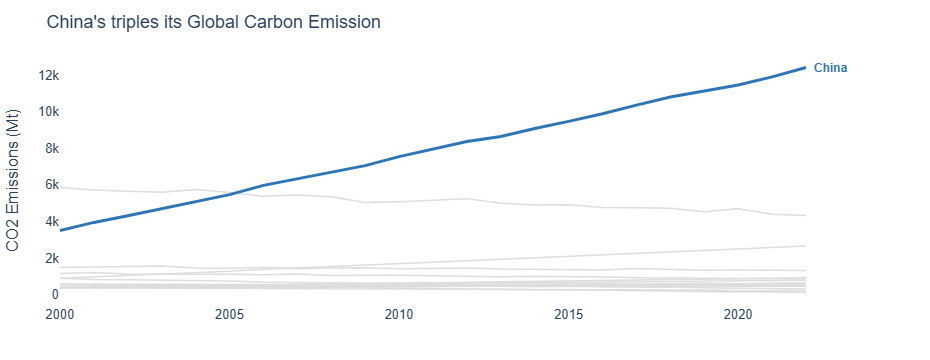

In [9]:
# Let's apply the principles

highlight = 'China'

# Build colour map: highlight in blue, everything else grey
color_map = {c: '#2E75B6' if c == highlight else '#DDDDDD' for c in df['Country'].unique()}

fig = px.line(df, x='Year', y='CO2_Mt', color='Country',
              color_discrete_map=color_map,
              labels={'CO2_Mt': 'CO2 Emissions (Mt)', 'Year': ''})

fig.update_traces(
    line=dict(width=1.5),   # default: thin for context countries
    showlegend=False      # direct label replaces legend (Gestalt proximity)
)

# Override highlighted country: thicker line
fig.update_traces(
    line=dict(width=3),
    selector=dict(name=highlight)
)

# Direct label at end of highlighted line
last = df.loc[(df['Country'] == highlight) & (df['Year'] == df['Year'].max())]

fig.add_annotation(
    x=last['Year'].values[0], y=last['CO2_Mt'].values[0],
    text=f'<b>{highlight}</b>', showarrow=False,
    xanchor='left', xshift=6,
    font=dict(color='#2E75B6', size=12, family='Arial')
)

fig.update_layout(
    title="China's triples its Global Carbon Emission",
    plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family='Arial', size=13),
    yaxis=dict( title='CO2 Emissions (Mt)'),
    xaxis=dict(showgrid=False, title=''),
    margin=dict(l=60, r=80, t=55, b=40)
)

fig.show()

## Task 1

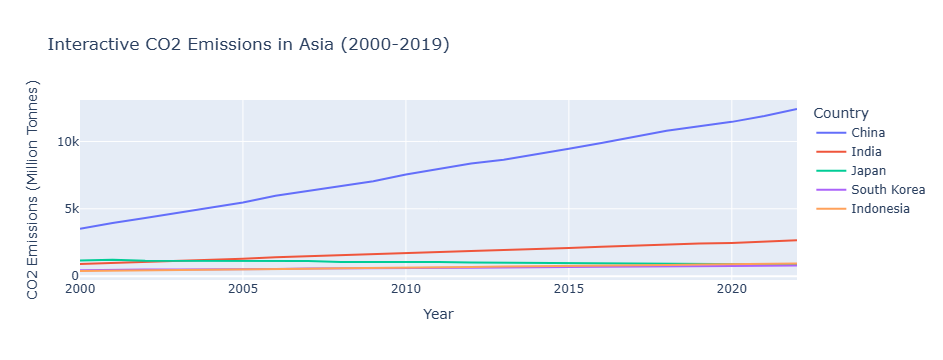

In [16]:
import pandas as pd
import plotly.express as px

# Load your data
df = pd.read_csv('data/co2_emissions.csv')

# Filter for the Asian region
asia_df = df[df['Region'] == 'Asia']

# Create an interactive line chart
fig = px.line(asia_df, 
              x='Year', 
              y='CO2_Mt', 
              color='Country', 
              title='Interactive CO2 Emissions in Asia (2000-2019)',
              labels={'CO2_Mt': 'CO2 Emissions (Million Tonnes)', 'Year': 'Year'})

fig.show()

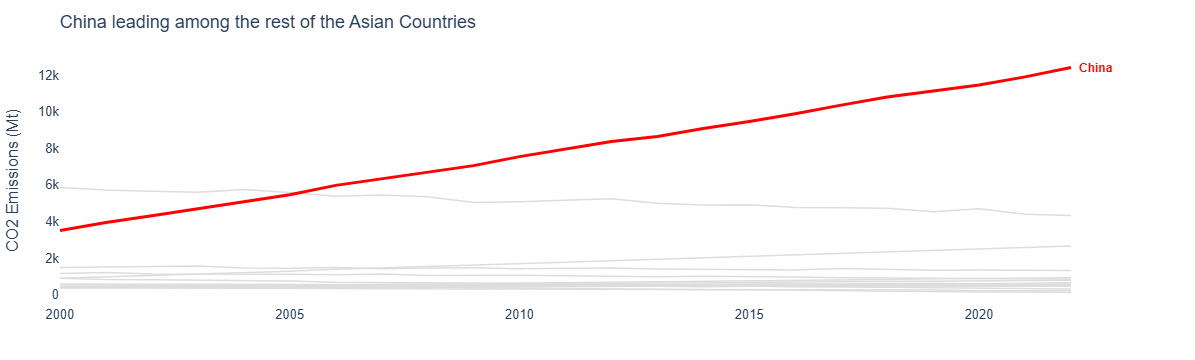

In [32]:
highlight = 'China'

# Build colour map: highlight in blue, everything else grey
color_map = {c: 'Red' if c == highlight else '#DDDDDD' for c in df['Country'].unique()}

fig = px.line(df, x='Year', y='CO2_Mt', color='Country',
              color_discrete_map=color_map,
              labels={'CO2_Mt': 'CO2 Emissions (Mt)', 'Year': ''})

fig.update_layout(
    title="China leading among the rest of the Asian Countries",
    plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family='Arial', size=13),
    yaxis=dict( title='CO2 Emissions (Mt)'),
    xaxis=dict(showgrid=False, title=''),
    margin=dict(l=60, r=80, t=55, b=40),
)

fig.update_traces(
    line=dict(width=1.5), 
    showlegend=False      
)

last = df.loc[(df['Country'] == highlight) & (df['Year'] == df['Year'].max())]

fig.add_annotation(
    x=last['Year'].values[0], y=last['CO2_Mt'].values[0],
    text=f'<b>{highlight}</b>', showarrow=False,
    xanchor='left', xshift=6,
    font=dict(color='Red', size=12, family='Arial')
)

fig.update_traces(
    line=dict(width=3),
    selector=dict(name=highlight)
)

fig.show()

---
## Task 2 — Slopegraph: Regional Change 2000 vs 2022

**What to build:** A slopegraph comparing **average regional CO2 emissions** between 2000 and 2022.

**Requirements:**
- One line per region (not per country — aggregate first)
- Colour: regions that increased = one colour; decreased = another
- Values labelled at both ends of each line
- No y-axis tick labels (the endpoint labels make them redundant)
- Insight title stating which regions moved most

> 💡 `df.groupby(['Region','Year'])['CO2_Mt'].mean().reset_index()` then filter to 2000 and 2022


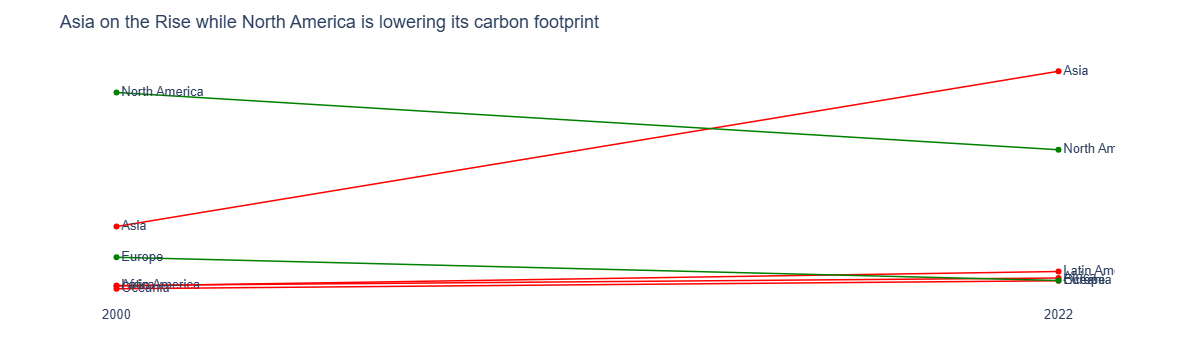

In [39]:
import pandas as pd
import plotly.express as px

# 1. Aggregate the data (Mean CO2 per Region/Year)
regional_avg = df.groupby(['Region', 'Year'])['CO2_Mt'].mean().reset_index()

# 2. Filter for specific years
slope_df = regional_avg[regional_avg['Year'].isin([2000, 2022])]

# 3. Create a helper to determine color (Increase vs Decrease)
pivot = slope_df.pivot(index='Region', columns='Year', values='CO2_Mt').reset_index()
pivot['Status'] = pivot.apply(lambda x: 'Increase' if x[2022] > x[2000] else 'Decrease', axis=1)

# Merge status back to the long dataframe for Plotly
slope_df = slope_df.merge(pivot[['Region', 'Status']], on='Region')

# 4. Build the Slopegraph
fig = px.line(slope_df, 
              x='Year', 
              y='CO2_Mt', 
              color='Status', 
              line_group='Region',
              hover_name='Region',
              text='Region', # Shows region name near the points
              title='Asia on the Rise while North America is lowering its carbon footprint',
              color_discrete_map={'Increase': 'red', 'Decrease': 'green'},
              markers=False,)

fig.update_layout(
    plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family='Arial', size=13),
    xaxis=dict(showgrid=False, title=''),
    margin=dict(l=60, r=80, t=55, b=40),
)

# Requirements: Labels at ends and no y-axis ticks
fig.update_traces(mode='lines+markers+text', textposition='middle right')
fig.update_yaxes(showticklabels=False, title="")
fig.update_xaxes(type='category')

fig.update_traces(
    line=dict(width=1.5), 
    showlegend=False      
)

fig.show()